In [1]:
import math
import seaborn as sns
import numpy as np
import scanpy as sc
import pandas as pd
from kneed import KneeLocator
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

### Loading pre-prcoessed data

In [2]:
# Loading AnnData object
select_region = "Isocortex-1"
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/")
expr_path = base_path / f"AnnData/WMB-10Xv3-{select_region}-raw-wmeta-DEGpp.h5ad"
adata = sc.read_h5ad(expr_path)
adata

AnnData object with n_obs × n_vars = 227325 × 2000
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'region_of_interest_order', 'region_of_interest_color', 'leiden', 'leiden_0.001', 'leiden_0.002', 'leiden_0.006', 'leiden_0.01', 'leiden_0.04', 'leiden_0.08', 'leiden_0.1', 'leiden_0.15', 'leiden_0.2', 'leiden_0.3'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'class_colors', 'hvg', 'leiden', 'leiden_0.001', 'leiden_0.002', 'leiden_0.006', 'leiden_0.006_colors', 'leiden_0.01', 'leiden_0.04', 'leiden_0.08', 'leiden_0.1', 'leiden_0.15', 'leiden_0.2', 'leiden_0.2_colors', 'leiden_0.3', 

### UMAP

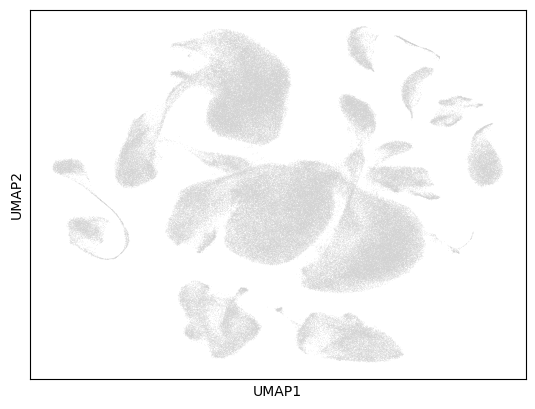

In [3]:
sc.pl.umap(adata)

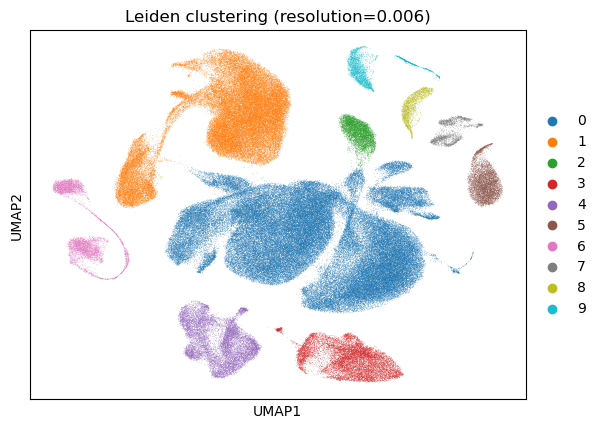

In [4]:
sc.pl.umap(adata, color=["leiden_0.006"], title="Leiden clustering (resolution=0.006)")

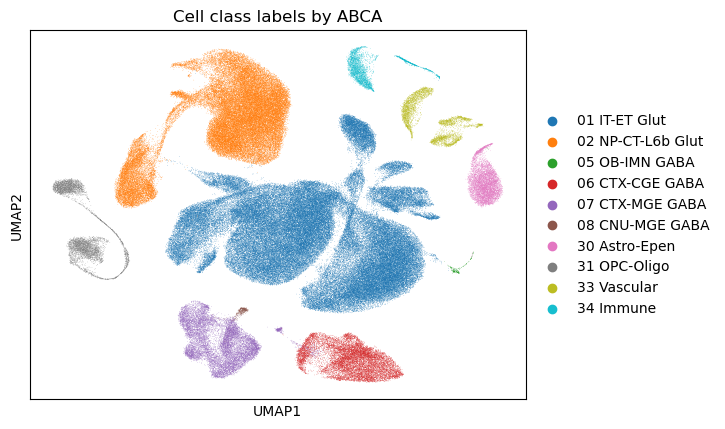

In [22]:
sc.pl.umap(adata, color=["class"], title="Cell class labels by ABCA")

### Silhouetee scores

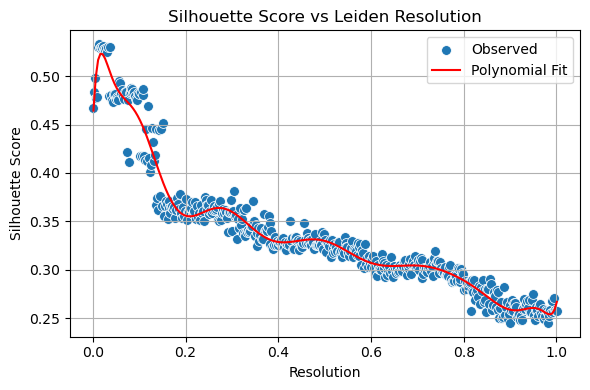

In [ ]:
df = pd.read_csv("silhouette_scores_by_resolution.csv")

# Fit a degree-3 polynomial
coeffs = np.polyfit(df["resolution"], df["silhouette_score"], deg=15)
poly_fn = np.poly1d(coeffs)

# Create smooth curve
x = np.linspace(df["resolution"].min(), df["resolution"].max(), 200)
y = poly_fn(x)

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="resolution", y="silhouette_score", s=50, label="Observed")
plt.plot(x, y, color='red', label='Polynomial Fit')
plt.title("Silhouette Score vs Leiden Resolution")
plt.xlabel("Resolution")
plt.ylabel("Silhouette Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

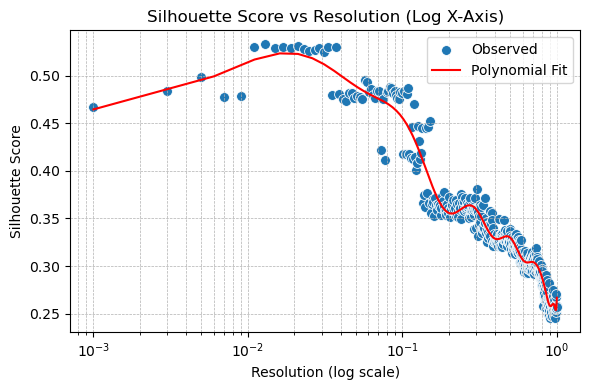

In [ ]:
# Load your data
df = pd.read_csv("silhouette_scores_by_resolution.csv")

# Drop any rows with NaNs or non-positive resolution (just in case)
df = df[(df["resolution"] > 0) & df["silhouette_score"].notna()].copy()

# Fit a polynomial on raw resolution values
coeffs = np.polyfit(df["resolution"], df["silhouette_score"], deg=15)
poly_fn = np.poly1d(coeffs)

# Create smooth curve over resolution range
x_fit = np.linspace(df["resolution"].min(), df["resolution"].max(), 200)
y_fit = poly_fn(x_fit)

# Plot
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="resolution", y="silhouette_score", s=50, label="Observed")
plt.plot(x_fit, y_fit, color='red', label='Polynomial Fit')

# Set x-axis to logarithmic scale
plt.xscale('log')
plt.xlabel("Resolution (log scale)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Resolution (Log X-Axis)")
plt.grid(True, which="both", ls="--", lw=0.5)
plt.legend()
plt.tight_layout()
plt.show()

### GO: Marker gene databases

In [28]:
import gseapy as gp

libs = gp.get_library_name()
libs

['ARCHS4_Cell-lines',
 'ARCHS4_IDG_Coexp',
 'ARCHS4_Kinases_Coexp',
 'ARCHS4_TFs_Coexp',
 'ARCHS4_Tissues',
 'Achilles_fitness_decrease',
 'Achilles_fitness_increase',
 'Aging_Perturbations_from_GEO_down',
 'Aging_Perturbations_from_GEO_up',
 'Allen_Brain_Atlas_10x_scRNA_2021',
 'Allen_Brain_Atlas_down',
 'Allen_Brain_Atlas_up',
 'Azimuth_2023',
 'Azimuth_Cell_Types_2021',
 'BioCarta_2013',
 'BioCarta_2015',
 'BioCarta_2016',
 'BioPlanet_2019',
 'BioPlex_2017',
 'CCLE_Proteomics_2020',
 'CORUM',
 'COVID-19_Related_Gene_Sets',
 'COVID-19_Related_Gene_Sets_2021',
 'Cancer_Cell_Line_Encyclopedia',
 'CellMarker_2024',
 'CellMarker_Augmented_2021',
 'ChEA_2013',
 'ChEA_2015',
 'ChEA_2016',
 'ChEA_2022',
 'Chromosome_Location',
 'Chromosome_Location_hg19',
 'ClinVar_2019',
 'DGIdb_Drug_Targets_2024',
 'DSigDB',
 'Data_Acquisition_Method_Most_Popular_Genes',
 'DepMap_CRISPR_GeneDependency_CellLines_2023',
 'DepMap_WG_CRISPR_Screens_Broad_CellLines_2019',
 'DepMap_WG_CRISPR_Screens_Sanger_Cell

In [43]:
libs[160:190]

['NIBR_DRUGseq_2025_up',
 'NIH_Funded_PIs_2017_AutoRIF_ARCHS4_Predictions',
 'NIH_Funded_PIs_2017_GeneRIF_ARCHS4_Predictions',
 'NIH_Funded_PIs_2017_Human_AutoRIF',
 'NIH_Funded_PIs_2017_Human_GeneRIF',
 'NURSA_Human_Endogenous_Complexome',
 'OMIM_Disease',
 'OMIM_Expanded',
 'Old_CMAP_down',
 'Old_CMAP_up',
 'Orphanet_Augmented_2021',
 'PFOCR_Pathways',
 'PFOCR_Pathways_2023',
 'PPI_Hub_Proteins',
 'PanglaoDB_Augmented_2021',
 'Panther_2015',
 'Panther_2016',
 'PerturbAtlas',
 'Pfam_Domains_2019',
 'Pfam_InterPro_Domains',
 'PheWeb_2019',
 'PhenGenI_Association_2021',
 'Phosphatase_Substrates_from_DEPOD',
 'ProteomicsDB_2020',
 'Proteomics_Drug_Atlas_2023',
 'RNA-Seq_Disease_Gene_and_Drug_Signatures_from_GEO',
 'RNAseq_Automatic_GEO_Signatures_Human_Down',
 'RNAseq_Automatic_GEO_Signatures_Human_Up',
 'RNAseq_Automatic_GEO_Signatures_Mouse_Down',
 'RNAseq_Automatic_GEO_Signatures_Mouse_Up']

In [ ]:
# Load DEG results
select_region = "Isocortex-1"
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/")
deg_dir = base_path / "outputs/DEG"
resolution = 0.006  # example resolution
deg_path = deg_dir / f"WMB-10Xv3-{select_region}-DEG-leiden_{resolution}.csv"
deg_df = pd.read_csv(deg_path)

# Store results in a dictionary
marker_enrichment_results = {}

# Loop over clusters
for cluster in deg_df.columns:
    top_genes = deg_df[cluster].dropna().tolist()[:100]

    result = gp.enrichr(
        gene_list=top_genes,
        gene_sets=["CellMarker_2024"], # "CellMarker_2024" , "PanglaoDB_Augmented_2021"
        organism='Mouse',
        outdir=None,
        cutoff=0.1
    )

    # Save to dictionary
    marker_enrichment_results[cluster] = result.results  # this is a Pandas DataFrame

    # # Also optionally save to CSV
    # result.results.to_csv(
    #     base_path / f"outputs/marker_enrichment_cluster_{cluster}_res{resolution}.csv", index=False
    # )

In [50]:
for cluster in deg_df.columns:
    # Get enriched terms for cluster "0"
    marker_enrichment_results[cluster].head()

    # Get top hit
    top_hit = marker_enrichment_results[cluster].iloc[0]
    print(f"Top marker match for cluster {cluster}: {top_hit['Term']} (p={top_hit['Adjusted P-value']:.2e})")

Top marker match for cluster 0: Neuron Brain Mouse (p=5.10e-14)
Top marker match for cluster 1: Neuron Brain Mouse (p=5.34e-12)
Top marker match for cluster 2: Excitatory Neuron Brain Mouse (p=2.93e-04)
Top marker match for cluster 3: Neuron Brain Human (p=2.26e-08)
Top marker match for cluster 4: GABAergic Neuron Brain Mouse (p=4.48e-09)
Top marker match for cluster 5: Astrocyte Brain Mouse (p=2.65e-62)
Top marker match for cluster 6: Oligodendrocyte Brain Mouse (p=2.10e-42)
Top marker match for cluster 7: Smooth Muscle Cell Brain Mouse (p=5.38e-23)
Top marker match for cluster 8: Endothelial Cell Brain Mouse (p=3.52e-65)
Top marker match for cluster 9: Microglial Cell Brain Mouse (p=9.42e-45)


In [53]:
# Load DEG results
select_region = "Isocortex-1"
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/")
deg_dir = base_path / "outputs/DEG"
resolution = 0.2  # example resolution
deg_path = deg_dir / f"WMB-10Xv3-{select_region}-DEG-leiden_{resolution}.csv"
deg_df2 = pd.read_csv(deg_path)

# Store results in a dictionary
marker_enrichment_results2 = {}

# Loop over clusters
for cluster in deg_df2.columns:
    top_genes = deg_df2[cluster].dropna().tolist()[:100]

    result = gp.enrichr(
        gene_list=top_genes,
        gene_sets=["PanglaoDB_Augmented_2021"], # "CellMarker_2024" , "PanglaoDB_Augmented_2021"
        organism='Mouse',
        outdir=None,
        cutoff=0.1
    )

    # Save to dictionary
    marker_enrichment_results2[cluster] = result.results  # this is a Pandas DataFrame

    # # Also optionally save to CSV
    # result.results.to_csv(
    #     base_path / f"outputs/marker_enrichment_cluster_{cluster}_res{resolution}.csv", index=False
    # )

In [52]:
for cluster in deg_df2.columns:
    # Get enriched terms for cluster "0"
    marker_enrichment_results2[cluster].head()

    # Get top hit
    top_hit = marker_enrichment_results2[cluster].iloc[0]
    print(f"Top marker match for cluster {cluster}: {top_hit['Term']} (p={top_hit['Adjusted P-value']:.2e})")

Top marker match for cluster 0: Neuron Brain Mouse (p=7.17e-05)
Top marker match for cluster 1: Neuron Brain Human (p=3.32e-07)
Top marker match for cluster 2: Lake Et al.Science.Ex6 Brain Human (p=5.77e-10)
Top marker match for cluster 3: Neuron Brain Mouse (p=3.96e-04)
Top marker match for cluster 4: Excitatory Neuron Brain Mouse (p=3.04e-04)
Top marker match for cluster 5: Type IC Spiral Ganglion Neuron Brain Mouse (p=6.69e-05)
Top marker match for cluster 6: Neuron Brain Human (p=1.71e-08)
Top marker match for cluster 7: Neuron Brain Human (p=1.23e-09)
Top marker match for cluster 8: GABAergic Neuron Brain Mouse (p=4.48e-09)
Top marker match for cluster 9: Lake Et al.Science.Ex6 Brain Human (p=3.40e-06)
Top marker match for cluster 10: Astrocyte Brain Mouse (p=2.65e-62)
Top marker match for cluster 11: Oligodendrocyte Precursor Cell Brain Mouse (p=4.69e-63)
Top marker match for cluster 12: Oligodendrocyte Brain Mouse (p=5.07e-41)
Top marker match for cluster 13: Smooth Muscle Cell 

### Clustering

In [17]:
# Using the igraph implementation and a fixed number of iterations can be significantly faster, especially for larger datasets
sc.tl.leiden(adata, flavor="igraph", n_iterations=2)

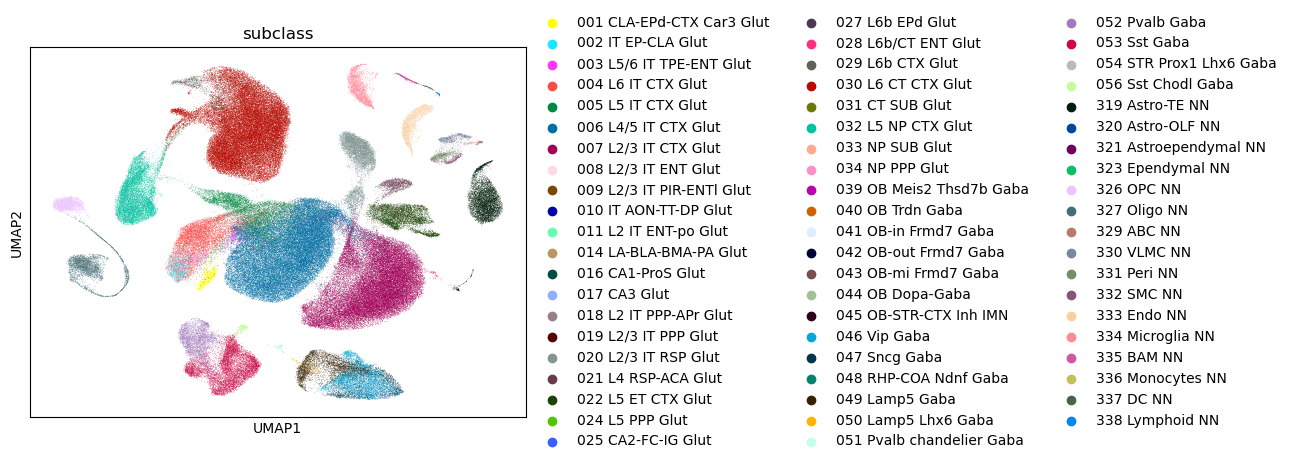

In [54]:
sc.pl.umap(adata, color=["subclass"])

In [55]:
it_glut_adata = adata[adata.obs["class"] == "01 IT-ET Glut"]

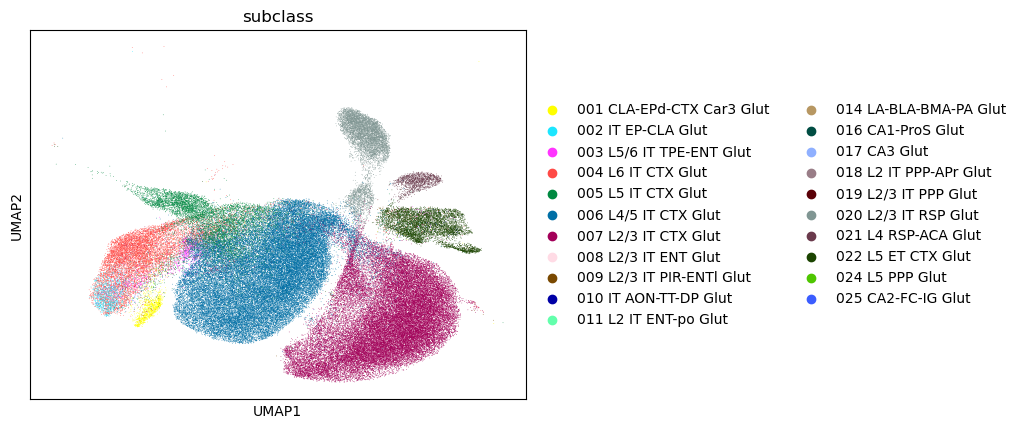

In [57]:
sc.pl.umap(it_glut_adata, color=["subclass"])

In [19]:
for res in [0.001,0.002,0.006,0.01]:
    sc.tl.leiden(adata, flavor="igraph", n_iterations=2, key_added=f'leiden_{res}', resolution=res)
    ari = adjusted_rand_score(adata.obs['class'], adata.obs[f'leiden_{res}'])
    print(f"Resolution {res} → ARI: {ari:.3f}")

Resolution 0.001 → ARI: 0.980
Resolution 0.002 → ARI: 0.980
Resolution 0.006 → ARI: 0.937
Resolution 0.01 → ARI: 0.937


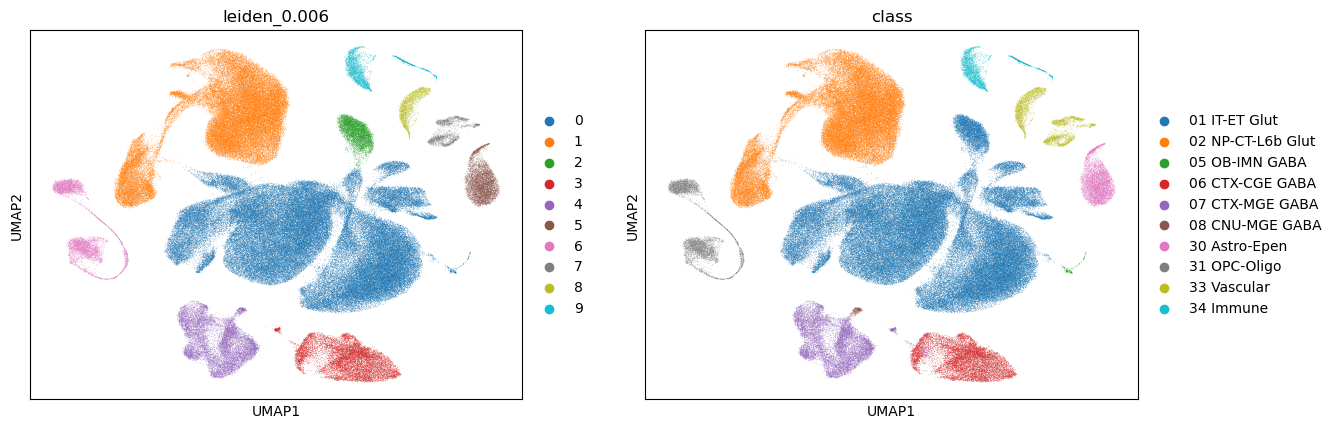

In [20]:
sc.pl.umap(adata, color=["leiden_0.006","class"])

In [21]:
for res in [0.04,0.08,0.1,0.15,0.2,0.3]:
    sc.tl.leiden(adata, flavor="igraph", n_iterations=2, key_added=f'leiden_{res}', resolution=res)
    ari = adjusted_rand_score(adata.obs['subclass'], adata.obs[f'leiden_{res}'])
    print(f"Resolution {res} → ARI: {ari:.3f}")

Resolution 0.04 → ARI: 0.691
Resolution 0.08 → ARI: 0.814
Resolution 0.1 → ARI: 0.822
Resolution 0.15 → ARI: 0.842
Resolution 0.2 → ARI: 0.850
Resolution 0.3 → ARI: 0.833


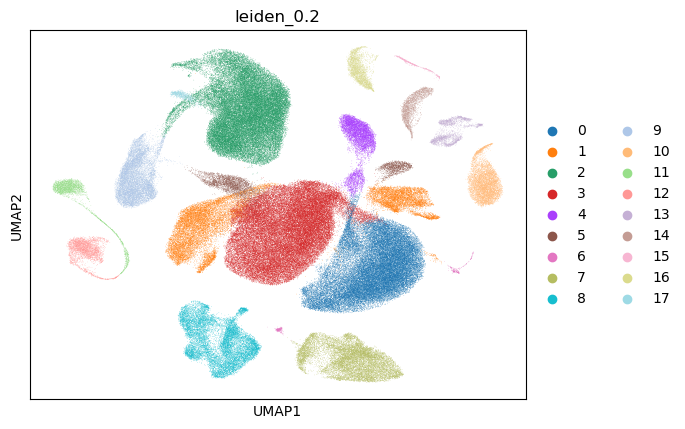

In [23]:
sc.pl.umap(adata, color=["leiden_0.2"])

In [25]:
sc.write(base_path / f"AnnData/WMB-10Xv3-{select_region}-raw-wmeta-DEGpp.h5ad",
         adata = adata)

In [ ]:
from sklearn.metrics import silhouette_score

for res in [0.001,0.002,0.006,0.01,0.04,0.08,0.1,0.15,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]:
    # Choose subset size
    n = 10000
    idx = np.random.choice(adata.n_obs, size=n, replace=False)

    # Subset PCA and cluster labels
    X_sub = adata.obsm["X_pca"][idx]
    labels_sub = adata.obs[f'leiden_{res}'].values[idx]

    # Compute silhouette score
    score = silhouette_score(X_sub, labels_sub)
    print(f"Resolution {res} → Silhouette Score: {score:.3f}")

Resolution 0.001 → Silhouette Score: 0.466
Resolution 0.002 → Silhouette Score: 0.468
Resolution 0.006 → Silhouette Score: 0.472
Resolution 0.01 → Silhouette Score: 0.473
Resolution 0.04 → Silhouette Score: 0.475
Resolution 0.08 → Silhouette Score: 0.484
Resolution 0.1 → Silhouette Score: 0.479
Resolution 0.15 → Silhouette Score: 0.364
Resolution 0.2 → Silhouette Score: 0.363
Resolution 0.3 → Silhouette Score: 0.350
Resolution 0.4 → Silhouette Score: 0.326
Resolution 0.5 → Silhouette Score: 0.329
Resolution 0.6 → Silhouette Score: 0.309
Resolution 0.7 → Silhouette Score: 0.301
Resolution 0.8 → Silhouette Score: 0.288
Resolution 0.9 → Silhouette Score: 0.263


In [ ]:
from sklearn.metrics import calinski_harabasz_score

for res in [0.001,0.002,0.006,0.01,0.04,0.08,0.1,0.15,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]:
    score = calinski_harabasz_score(adata.obsm["X_pca"], adata.obs[f'leiden_{res}'])
    print(f"Resolution {res} → CH Score: {score:.3f}")

Resolution 0.001 → CH Score: 85700.555
Resolution 0.002 → CH Score: 85700.219
Resolution 0.006 → CH Score: 108587.242
Resolution 0.01 → CH Score: 108585.258
Resolution 0.04 → CH Score: 135139.266
Resolution 0.08 → CH Score: 224599.344
Resolution 0.1 → CH Score: 214125.094
Resolution 0.15 → CH Score: 203010.438
Resolution 0.2 → CH Score: 206772.094
Resolution 0.3 → CH Score: 191031.219
Resolution 0.4 → CH Score: 176743.000
Resolution 0.5 → CH Score: 174845.297
Resolution 0.6 → CH Score: 173590.297
Resolution 0.7 → CH Score: 167338.344
Resolution 0.8 → CH Score: 175289.812
Resolution 0.9 → CH Score: 160001.547


In [ ]:
def evaluate_ch_distribution(adata, pca_key="X_pca", clustering_key="leiden", 
                              resolutions=np.arange(0.2, 2.1, 0.2), 
                              n_samples=10, subsample_size=5000, random_seed=42):
    np.random.seed(random_seed)
    all_scores = []

    for res in resolutions:
        res_scores = []

        # Run clustering at this resolution
        sc.tl.leiden(adata, resolution=res, key_added=f'{clustering_key}_{res:.3f}', flavor="igraph", n_iterations=2)

        for i in range(n_samples):
            idx = np.random.choice(adata.n_obs, size=subsample_size, replace=False)
            X_sub = adata.obsm[pca_key][idx]
            labels_sub = adata.obs[f'{clustering_key}_{res:.3f}'].values[idx]

            # Compute CH score
            try:
                score = calinski_harabasz_score(X_sub, labels_sub)
            except:
                score = np.nan  # e.g. if only one cluster
            res_scores.append(score)

        all_scores.append((res, res_scores))

    return all_scores


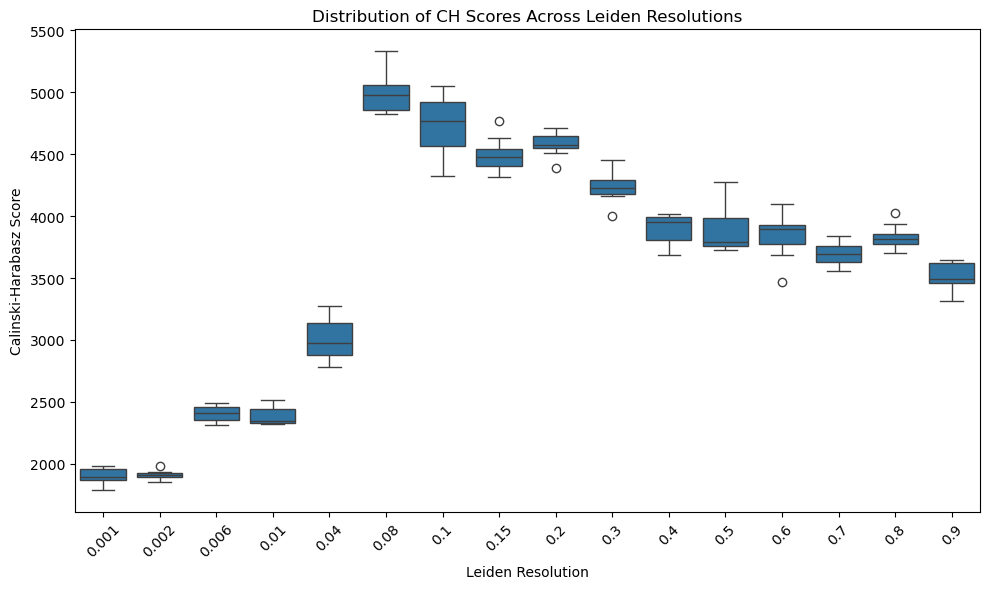

In [ ]:
# Run it
scores = evaluate_ch_distribution(adata,
    resolutions=[0.001,0.002,0.006,0.01,0.04,0.08,0.1,0.15,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]) # np.arange(0.001, 0.3, 0.002)

# Convert to boxplot-ready format
score_data = []
for res, vals in scores:
    for v in vals:
        score_data.append({'Resolution': res, 'CH Score': v})
df = pd.DataFrame(score_data)

# Plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Resolution', y='CH Score')
plt.title("Distribution of CH Scores Across Leiden Resolutions")
plt.xlabel("Leiden Resolution")
plt.ylabel("Calinski-Harabasz Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
def ch_score_across_resolutions(adata, 
                                 pca_key="X_pca", 
                                 clustering_key="leiden", 
                                 resolutions=np.linspace(0.1, 2.0, 40),
                                 subsample_size=5000,
                                 random_seed=42):
    np.random.seed(random_seed)
    X_pca = adata.obsm[pca_key]
    all_scores = []

    for res in resolutions:
        print("res: ", res)
        key = f'{clustering_key}_{res:.2f}'
        sc.tl.leiden(adata, resolution=res, key_added=key, flavor="igraph", n_iterations=2)
        labels = adata.obs[key].values

        # Subsample once per resolution
        idx = np.random.choice(adata.n_obs, size=subsample_size, replace=False)
        try:
            score = calinski_harabasz_score(X_pca[idx], labels[idx])
        except:
            score = np.nan  # if clustering fails or only one cluster

        all_scores.append({'Resolution': res, 'CH Score': score})

    return pd.DataFrame(all_scores)

res:  0.1
res:  0.14871794871794872
res:  0.19743589743589746
res:  0.24615384615384617
res:  0.2948717948717949
res:  0.3435897435897436
res:  0.39230769230769236
res:  0.441025641025641
res:  0.4897435897435898
res:  0.5384615384615384
res:  0.5871794871794872
res:  0.6358974358974359
res:  0.6846153846153846
res:  0.7333333333333333
res:  0.782051282051282
res:  0.8307692307692307
res:  0.8794871794871795
res:  0.9282051282051282
res:  0.9769230769230769
res:  1.0256410256410258
res:  1.0743589743589743
res:  1.123076923076923
res:  1.1717948717948719
res:  1.2205128205128206
res:  1.2692307692307694
res:  1.3179487179487182
res:  1.3666666666666667
res:  1.4153846153846155
res:  1.4641025641025642
res:  1.512820512820513
res:  1.5615384615384615
res:  1.6102564102564103
res:  1.658974358974359
res:  1.7076923076923078
res:  1.7564102564102566
res:  1.8051282051282052
res:  1.853846153846154
res:  1.9025641025641027
res:  1.9512820512820515
res:  2.0


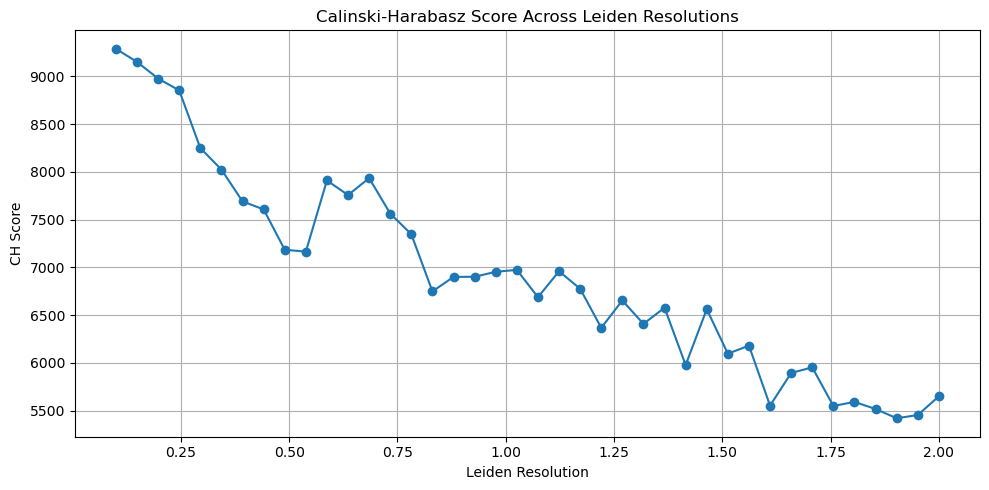

In [61]:
df_ch = ch_score_across_resolutions(adata,
                                    resolutions=np.linspace(0.1, 2.0, 40),
                                    subsample_size=10000
                                    )

plt.figure(figsize=(10, 5))
plt.plot(df_ch['Resolution'], df_ch['CH Score'], marker='o')
plt.title("Calinski-Harabasz Score Across Leiden Resolutions")
plt.xlabel("Leiden Resolution")
plt.ylabel("CH Score")
plt.grid(True)
plt.tight_layout()
plt.show()

### DE

In [ ]:
# Perform differential expression analysis
group_by="leiden_0.006"
sc.tl.rank_genes_groups(
    adata,
    key_added=f"rank_genes_{group_by}",
    groupby=group_by,
    method="wilcoxon",
    use_raw=True
)

In [ ]:
def get_top_markers(adata, n_top=50):
    result = adata.uns[f"rank_genes_{group_by}"]
    groups = result['names'].dtype.names
    markers = {
        group: [result['names'][group][i] for i in range(n_top)]
        for group in groups
    }
    return markers

top_markers = get_top_markers(adata, n_top=50)

In [ ]:
import gseapy as gp

# For one cluster, say cluster "0"
genes_cluster_0 = top_markers["0"]

enr = gp.enrichr(
    gene_list=genes_cluster_0,
    gene_sets=["CellMarker_2019", "PanglaoDB_2021"],  # Use both
    organism='Mouse',
    no_plot=True,
    outdir=None,
)

# View top cell types that match
enr.results.head(10)

In [9]:
# Extract the differential expression results
deg_results = pd.DataFrame({
    group: pd.DataFrame(adata.uns["rank_genes_groups"]["names"])[group]
    for group in adata.uns["rank_genes_groups"]["names"].dtype.names
})

# Save the dataframe to a CSV file
output_path = base_path / "outputs/DEG/" / f"WMB-10Xv3-{select_region}-DEG-{group_by}.csv"
deg_results.to_csv(output_path, index=False)

print(f"Differentially expressed genes saved to {output_path}")

Differentially expressed genes saved to /data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs/DEG/WMB-10Xv3-Isocortex-1-DEG-class.csv


In [10]:
deg_results.head()

,01 IT-ET Glut,02 NP-CT-L6b Glut,05 OB-IMN GABA,06 CTX-CGE GABA,07 CTX-MGE GABA,08 CNU-MGE GABA,30 Astro-Epen,31 OPC-Oligo,33 Vascular,34 Immune
0,C1ql3,Hs3st4,H3f3b,Adarb2,Kcnc2,Sox2ot,Plpp3,Olig1,Sparc,Laptm5
1,Cck,Cdh18,Zbtb20,Dlx6os1,Rab3b,Alk,Slc1a3,Qk,Utrn,Inpp5d
2,Tafa1,Foxp2,Msi2,Gad1,Slc32a1,Nkain3,Slc1a2,Gjc3,Zbtb20,Cst3
3,Bdnf,Nxph3,Sox4,Erbb4,Nxph1,Crhbp,Mt1,Sox10,Epas1,Serinc3
4,Nrgn,Rprm,Ttc28,Zfp536,Grip1,Npy,Gja1,Bcas1,Gng5,Csf1r


## Visualization
https://scanpy.readthedocs.io/en/stable/tutorials/plotting/core.html

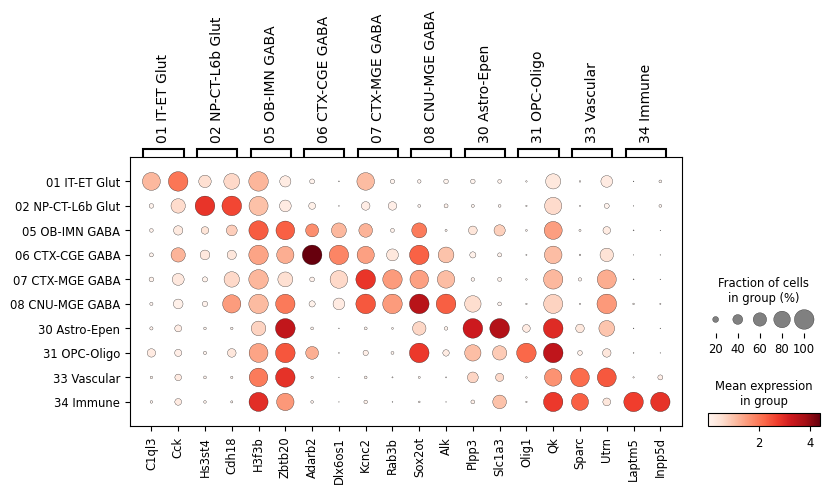

In [10]:
sc.pl.rank_genes_groups_dotplot(adata, n_genes=2, dendrogram=False)

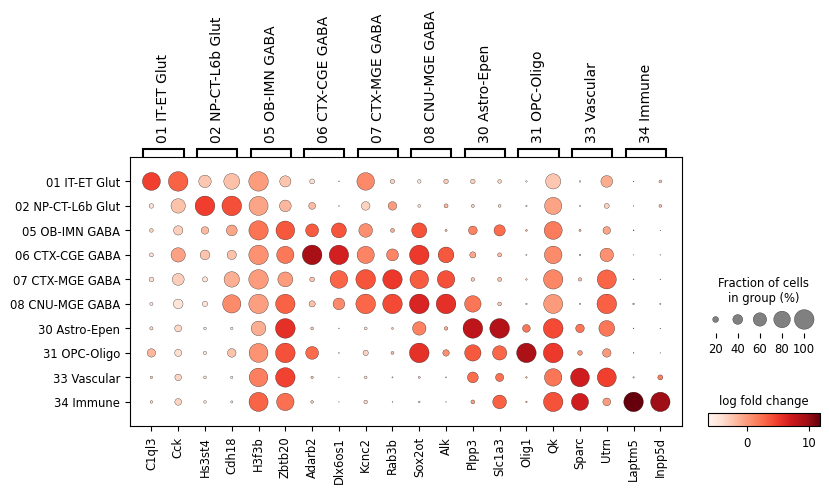

In [11]:
sc.pl.rank_genes_groups_dotplot(adata, n_genes=2, values_to_plot="logfoldchanges", dendrogram=False)

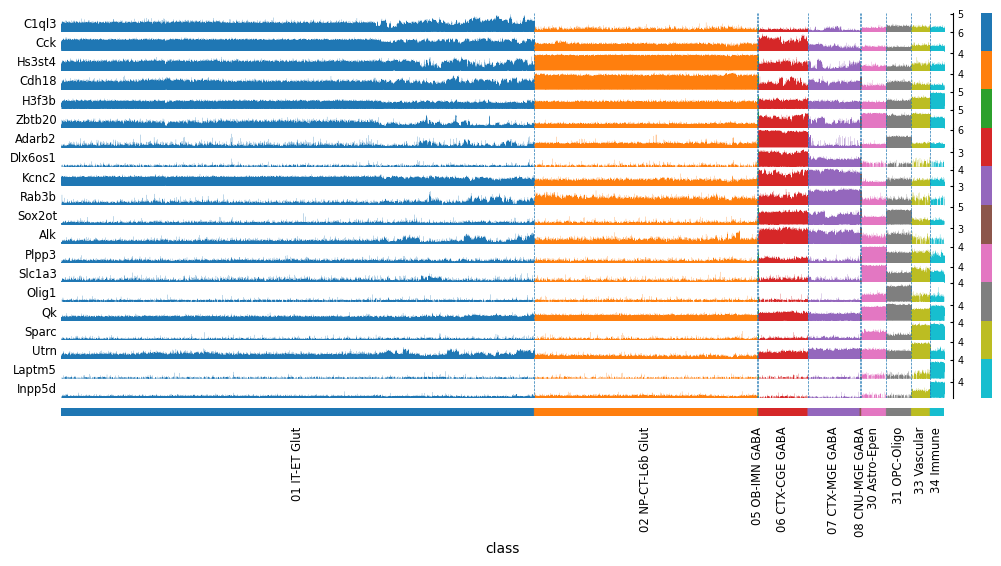

In [12]:
sc.pl.rank_genes_groups_tracksplot(adata, n_genes=2, dendrogram=False)

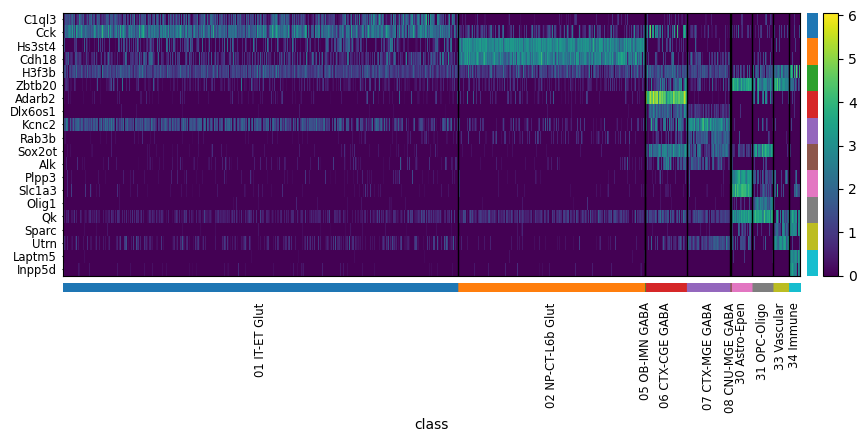

In [13]:
sc.pl.rank_genes_groups_heatmap(adata, n_genes=2, dendrogram=False, swap_axes=True)

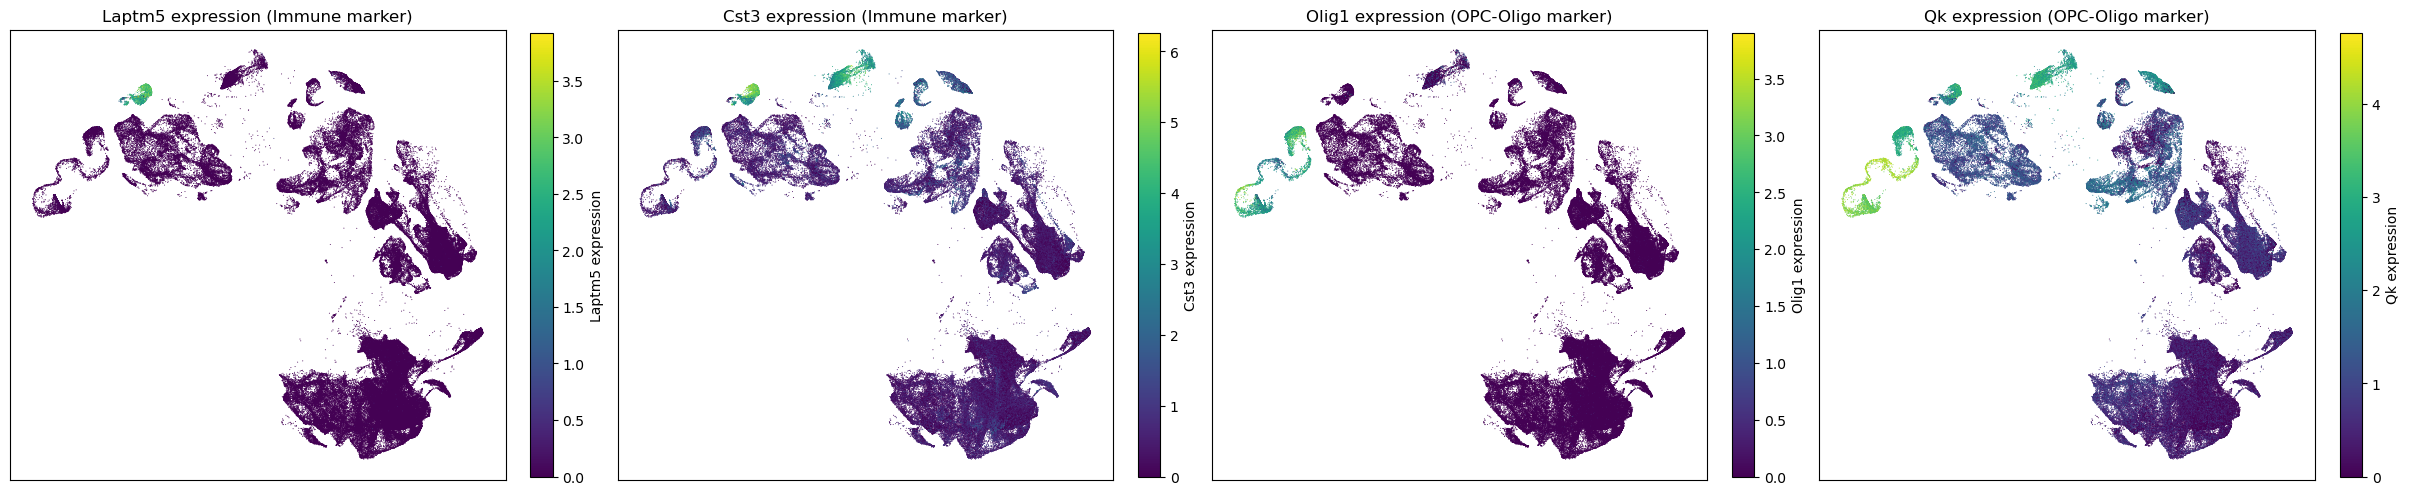

In [ ]:
# Selecting genes to plot
top_genes = ["Laptm5", "Cst3", "Olig1", "Qk"]

# Create a figure with subplots
fig, axes = plt.subplots(1, len(top_genes), figsize=(6 * len(top_genes), 6), constrained_layout=True)

# If there's only one gene, make sure axes is iterable
if len(top_genes) == 1:
    axes = [axes]

# Plot the expression of each gene using UMAP coordinates from adata.obs
for ax, gene in zip(axes, top_genes):
    scatter = ax.scatter(
        adata.obs["x"],
        adata.obs["y"],
        c=adata[:, gene].X.toarray().flatten(),
        cmap="viridis",
        s=0.5,
        edgecolor="none"
    )
    fig.colorbar(scatter, ax=ax, shrink = 0.75, label=f"{gene} expression")
    if gene in ["Laptm5", "Cst3"]:
        ax.set_title(f"{gene} expression (Immune marker)")
    elif gene in ["Qk", "Olig1"]:
        ax.set_title(f"{gene} expression (OPC-Oligo marker)")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')

plt.show()

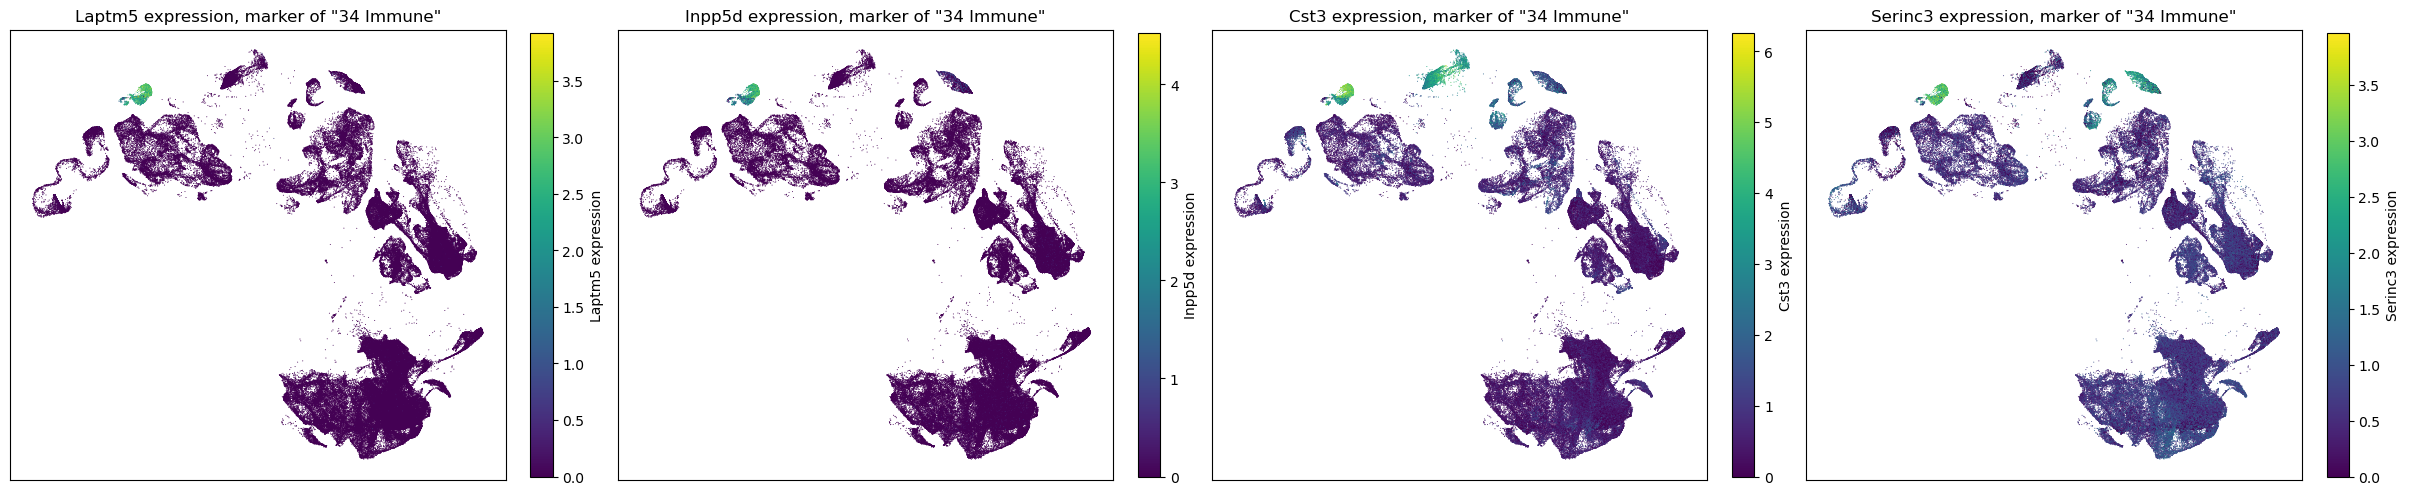

In [ ]:
# Select a group and get the top genes
group = "34 Immune"
top_genes = deg_results[group].head(4)

# Create a figure with subplots
fig, axes = plt.subplots(1, len(top_genes), figsize=(6 * len(top_genes), 6), constrained_layout=True)

# If there's only one gene, make sure axes is iterable
if len(top_genes) == 1:
    axes = [axes]

# Plot the expression of each gene using UMAP coordinates from adata.obs
for ax, gene in zip(axes, top_genes):
    scatter = ax.scatter(
        adata.obs["x"],
        adata.obs["y"],
        c=adata[:, gene].X.toarray().flatten(),
        cmap="viridis",
        s=0.5,
        edgecolor="none"
    )
    fig.colorbar(scatter, ax=ax, shrink = 0.75, label=f"{gene} expression")
    ax.set_title(f"{gene} expression, marker of \"{group}\"")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')

plt.show()

### Specificity

In [31]:
# Compute Tau scores
def compute_tau_score(adata, cluster_name, n_genes, group_by="class"):
    
    # Get expression matrix for the given cluster
    deg_expression_matrix = pd.DataFrame(
    adata.X.toarray(),  # Convert sparse matrix to dense
    index=adata.obs[group_by],  # Use the group_by column as the index
    columns=adata.var.index  # Use gene names as columns
    )

    # Select the top genes for the given cluster
    top_genes = deg_results[cluster_name].head(n_genes)

    # Compute Tau score for each gene
    tau_scores = {}
    for gene in top_genes:
        expression_values = deg_expression_matrix[gene]
        max_expression = expression_values.max()
        if max_expression > 0:
            normalized_expression = 1 - (expression_values / max_expression)
            tau_score = normalized_expression.sum() / (len(expression_values) - 1)
            tau_scores[gene] = tau_score
        else:
            tau_scores[gene] = 0

    # Convert to DataFrame
    tau_scores_df = pd.DataFrame(list(tau_scores.items()), columns=["Gene", "Tau Score"])
    return tau_scores_df

# Prompt for cluster name and number of genes
cluster_name = "34 Immune"
n_genes = 4

# Compute Tau scores
tau_scores_df = compute_tau_score(adata, cluster_name, n_genes)
print(tau_scores_df)

      Gene  Tau Score
0   Laptm5   0.987986
1   Inpp5d   0.985389
2     Cst3   0.894455
3  Serinc3   0.833388


## Validation

### Biological relevance: GO enrichment analysis

In [21]:
from gprofiler import GProfiler

# Parameters
n_top_genes = 50  # Number of top DEGs to include per cluster
organism = "mmusculus"  # Mouse gene symbols (use "hsapiens" for human)

# Initialize g:Profiler client
gp = GProfiler(return_dataframe=True)

# Store all results
go_enrichment_results = []

# Loop through each cluster in the DEG results
for cluster in deg_results.columns:
    # Get the top n DEGs for the cluster
    top_genes = deg_results[cluster].dropna().head(n_top_genes).tolist()
    
    # Skip clusters with no DEGs
    if not top_genes:
        print(f"Skipping {cluster}: no DEGs found.")
        continue
    
    # Perform GO enrichment analysis
    enrichment_result = gp.profile(
        organism=organism,
        query=top_genes,
        sources=["GO:BP"]  # Biological Process, Molecular Function, Cellular Component, "GO:MF", "GO:CC"
    )
    
    # Add cluster name to the results
    enrichment_result["cluster"] = cluster
    go_enrichment_results.append(enrichment_result)

# Combine all results into a single DataFrame
go_results_df = pd.concat(go_enrichment_results, ignore_index=True)

# Display the first few rows of the results
go_results_df.head()

,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents,cluster
0,GO:BP,GO:0048731,system development,1.533275e-08,True,"""The process whose specific outcome is the pro...",4123,48,28,26963,0.583333,0.006791,query_1,"[GO:0007275, GO:0048856]",01 IT-ET Glut
1,GO:BP,GO:0007275,multicellular organism development,1.414122e-07,True,"""The biological process whose specific outcome...",4886,48,29,26963,0.604167,0.005935,query_1,"[GO:0032501, GO:0048856]",01 IT-ET Glut
2,GO:BP,GO:0048856,anatomical structure development,2.170873e-06,True,"""The biological process whose specific outcome...",6290,48,31,26963,0.645833,0.004928,query_1,[GO:0032502],01 IT-ET Glut
3,GO:BP,GO:0050793,regulation of developmental process,2.339104e-06,True,"""Any process that modulates the frequency, rat...",2699,48,21,26963,0.437500,0.007781,query_1,"[GO:0032502, GO:0050789]",01 IT-ET Glut
4,GO:BP,GO:0032502,developmental process,3.858947e-06,True,"""A biological process whose specific outcome i...",6876,48,32,26963,0.666667,0.004654,query_1,[GO:0008150],01 IT-ET Glut


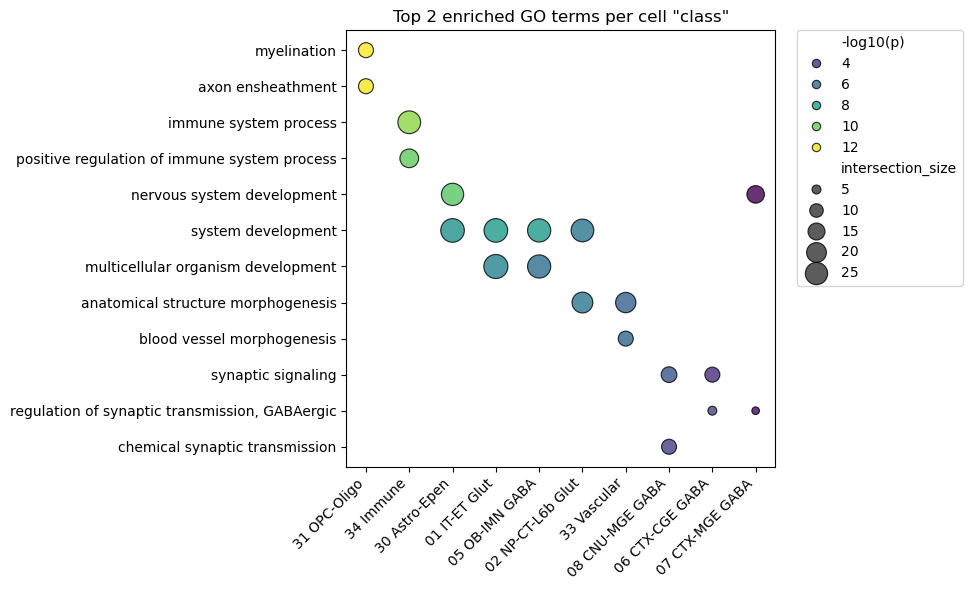

In [30]:
# ---------------------------------------------
# Parameters
# ---------------------------------------------
top_n = 2  # Top terms per cluster to include

# ---------------------------------------------
# Select top N enriched terms per cluster
# ---------------------------------------------
top_terms_df = (
    go_results_df
    .sort_values("p_value")
    .groupby("cluster")
    .head(top_n)
    .copy()
)

# Shorten term names for better plotting
top_terms_df["term_display"] = top_terms_df["name"].str.slice(0, 50)
top_terms_df["-log10(p)"] = -np.log10(top_terms_df["p_value"] + 1e-300)

# Optional: sort GO terms by frequency of appearance across clusters
term_order = (
    top_terms_df["term_display"]
    .value_counts()
    .index.tolist()
)

# ---------------------------------------------
# Create the Dot Plot
# ---------------------------------------------
plt.figure(figsize=(10, max(6, 0.4 * len(term_order))))
sns.scatterplot(
    data=top_terms_df,
    x="cluster",
    y="term_display",
    size="intersection_size",
    hue="-log10(p)",
    sizes=(30, 300),
    palette="viridis",
    edgecolor="black",
    alpha=0.8,
)

# Improve layout
plt.xticks(rotation=45, ha="right")
plt.ylabel("") # "GO term"
plt.xlabel("") # "Cell class"
plt.title(f"Top {top_n} enriched GO terms per cell \"class\"")

# Legends
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

### Statistical robustness: permutation test via label shuffling

* Shuffle the "class" labels in .obs
* Run DE analysis on the shuffled labels
* Collect top DE genes or statistics (e.g., adjusted p-values or log fold changes)
* Repeat this process multiple times (e.g., 100–1000 permutations)
* Compare your real DEGs to this null distribution to assess how likely they are to arise by chance

In [9]:
from joblib import Parallel, delayed

group_by  = "class"          # same as you used for the original DE call
method    = "wilcoxon"       # or 't-test_overestim_var', etc.
n_perms   = 100              # 1 000 is OK; >5 000 gives smoother tails
n_jobs    = -1               # how many CPU cores to use (‑1 == all)

In [10]:
# ------------------------------------------------------------------
# 1.  Run the observed DE test once                             
# ------------------------------------------------------------------
sc.tl.rank_genes_groups(adata, groupby=group_by, method=method, use_raw=False)

# Capture the observed statistics in a convenient dictionary
def _collect_scores(ad):
    res = {}
    names  = ad.uns["rank_genes_groups"]["names"]
    scores = ad.uns["rank_genes_groups"]["scores"]  # test statistic
    for clust in names.dtype.names:
        for g, s in zip(names[clust], scores[clust]):
            res[(clust, g)] = s
    return res

observed_scores = _collect_scores(adata)

In [11]:
# ------------------------------------------------------------------
# 2.  Single‑permutation helper  (runs in parallel)               
# ------------------------------------------------------------------
def _permute_and_score(ad, seed=None):
    """Shuffle the labels and return a dict { (cluster, gene): score }."""
    rng  = np.random.default_rng(seed)
    ad_p = ad.copy()
    ad_p.obs[group_by] = rng.permutation(ad_p.obs[group_by].values)
    sc.tl.rank_genes_groups(ad_p, groupby=group_by, method=method, use_raw=False)
    return _collect_scores(ad_p)

In [12]:
# ------------------------------------------------------------------
# 3.  Run the permutation test                                   
# ------------------------------------------------------------------
perm_dicts = Parallel(n_jobs=n_jobs, verbose=10)(
                delayed(_permute_and_score)(adata, seed)
                for seed in range(n_perms)
             )

# Bring the permutation scores into a single DataFrame
perm_df = (pd.DataFrame(perm_dicts)          # columns = permutations
             .T                              # rows   = (cluster, gene)
             .fillna(0.0)                    # gene may drop out of top‑N
)
perm_df.index = pd.MultiIndex.from_tuples(perm_df.index,
                                          names=["cluster", "gene"])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 56 concurrent workers.
[Parallel(n_jobs=-1)]: Done  11 out of 100 | elapsed:  2.2min remaining: 17.4min
[Parallel(n_jobs=-1)]: Done  22 out of 100 | elapsed:  2.2min remaining:  7.8min
[Parallel(n_jobs=-1)]: Done  33 out of 100 | elapsed:  2.3min remaining:  4.6min
[Parallel(n_jobs=-1)]: Done  44 out of 100 | elapsed:  2.3min remaining:  2.9min
[Parallel(n_jobs=-1)]: Done  55 out of 100 | elapsed:  2.3min remaining:  1.9min
[Parallel(n_jobs=-1)]: Done  66 out of 100 | elapsed:  3.9min remaining:  2.0min
[Parallel(n_jobs=-1)]: Done  77 out of 100 | elapsed:  3.9min remaining:  1.2min
[Parallel(n_jobs=-1)]: Done  88 out of 100 | elapsed:  4.0min remaining:   32.4s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  4.0min finished


In [ ]:
# ------------------------------------------------------------------
# 4.  Empirical p‑values  (1‑sided: permutation score ≥ observed) 
# ------------------------------------------------------------------
p_vals = {}
for key, obs_s in observed_scores.items():
    perm_s = perm_df.loc[key].values           # vector length = n_perms
    p_vals[key] = (np.sum(perm_s >= obs_s) + 1) / (n_perms + 1)

# --- patch: create a MultiIndex with level names ------------------
pval_s = pd.Series(p_vals)
pval_s.index = pd.MultiIndex.from_tuples(pval_s.index,
                                         names=["cluster", "gene"])

# genes × clusters DataFrame
pval_df = (pval_s
             .unstack(level="cluster")         # or: .unstack(0)
             .sort_index()
)

# Optional: Benjamini–Hochberg FDR across all tests
from statsmodels.stats.multitest import multipletests
flat_p   = pval_df.stack().values
fdr_adj  = multipletests(flat_p, method="fdr_bh")[1]
fdr_df   = pd.Series(fdr_adj,
                     index=pval_df.stack().index).unstack(level="cluster")

# Save for downstream use
# pval_df.to_csv("DEG_permutation_empirical_pvals.csv")
# fdr_df.to_csv("DEG_permutation_FDR.csv")

In [31]:
# -----------------------------------------------
# Choose the cluster you're interested in
# -----------------------------------------------
cluster = "34 Immune"    # <- change this to your target cluster name

# -----------------------------------------------
# Extract Scanpy DE results for that cluster
# -----------------------------------------------
# Convert the rank_genes_groups result to a DataFrame
de_result = pd.DataFrame({
    "gene": adata.uns["rank_genes_groups"]["names"][cluster],
    "score": adata.uns["rank_genes_groups"]["scores"][cluster],
    "logfoldchanges": adata.uns["rank_genes_groups"]["logfoldchanges"][cluster],
    "pval": adata.uns["rank_genes_groups"]["pvals"][cluster],
    "pval_adj": adata.uns["rank_genes_groups"]["pvals_adj"][cluster]
})

# -----------------------------------------------
# Add the empirical p-values from the permutation test
# -----------------------------------------------
# Join using gene name as index
de_result["empirical_pval"] = pval_df[cluster].reindex(de_result["gene"].values).values

# Sort by test statistic (descending), matching Scanpy's order
de_result_sorted = de_result.sort_values("score", ascending=False)

# Optional: view top DEGs by score
de_result_sorted.head(10)

,gene,score,logfoldchanges,pval,pval_adj,empirical_pval
0,Laptm5,102.325294,11.670257,0.0,0.0,0.009901
1,Inpp5d,101.471146,9.586122,0.0,0.0,0.009901
2,Cst3,100.360229,6.652828,0.0,0.0,0.009901
3,Serinc3,99.846977,4.060781,0.0,0.0,0.009901
4,Csf1r,99.571075,11.067130,0.0,0.0,0.009901
5,Zfhx3,99.061943,7.044516,0.0,0.0,0.009901
6,Lyn,98.561783,6.245395,0.0,0.0,0.009901
7,C1qa,98.362793,11.615284,0.0,0.0,0.009901
8,Tyrobp,98.218712,11.134317,0.0,0.0,0.009901
9,C1qc,98.145554,11.758708,0.0,0.0,0.009901


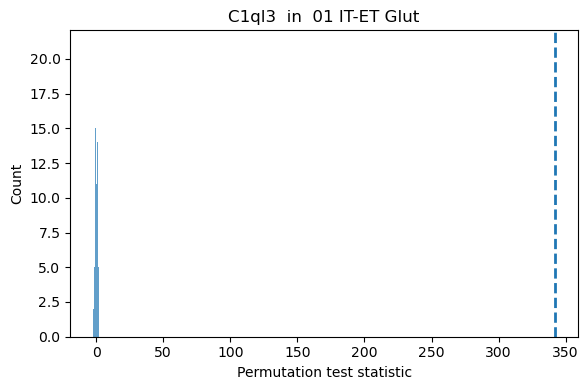

In [32]:
# ------------------------------------------------------------------
# 5.  Visualisation                                              
# ------------------------------------------------------------------
## 5a. Distribution check for a single (cluster, gene) ------------
example_cluster = list(observed_scores.keys())[0][0]   # pick the first cluster
example_gene    = list(observed_scores.keys())[0][1]   # and first gene

perm_scores = perm_df.loc[(example_cluster, example_gene)].values
obs_score   = observed_scores[(example_cluster, example_gene)]

plt.figure(figsize=(6,4))
plt.hist(perm_scores, bins=10, alpha=0.7)
plt.axvline(obs_score, ls="--", lw=2)
plt.xlabel("Permutation test statistic")
plt.ylabel("Count")
plt.title(f"{example_gene}  in  {example_cluster}")
plt.tight_layout()
plt.show()

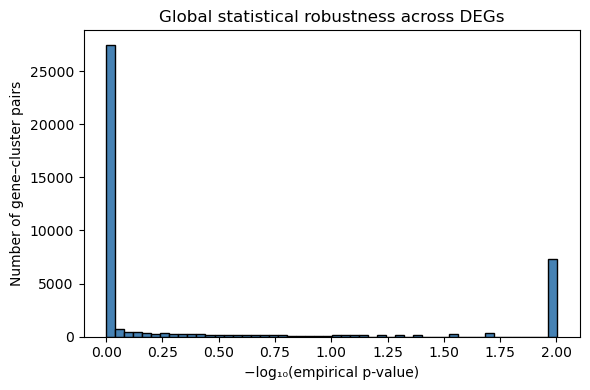

In [ ]:
# Histogram of all permutation p-values (−log10)
all_pvals = pval_df.values.flatten()
all_pvals = all_pvals[~np.isnan(all_pvals)]     # Remove NaNs if any

plt.figure(figsize=(6, 4))
plt.hist(-np.log10(all_pvals + 1e-300), bins=50, color="steelblue", edgecolor="k")
plt.xlabel("−log₁₀(empirical p-value)")
plt.ylabel("Number of gene–cluster pairs")
plt.title("Global statistical robustness across DEGs")
plt.tight_layout()
plt.show()

### Biological relevance: pathway enrichment analysis

In [38]:
from gprofiler import GProfiler

# ---------------------------------------------
# Parameters
# ---------------------------------------------
empirical_threshold = 0.01  # only test DEGs with empirical p < 0.01
organism = "mmusculus"      # mouse gene symbols (use "hsapiens" for human)

# ---------------------------------------------
# Initialize g:Profiler client
# ---------------------------------------------
gp = GProfiler(return_dataframe=True)

# ---------------------------------------------
# Store all results
# ---------------------------------------------
all_enrichments = []

# Loop through each cluster in the empirical p-value table
for cluster in pval_df.columns:
    # 1. Get DE result from Scanpy
    de_result = pd.DataFrame({
        "gene": adata.uns["rank_genes_groups"]["names"][cluster],
        "score": adata.uns["rank_genes_groups"]["scores"][cluster],
        "logfoldchanges": adata.uns["rank_genes_groups"]["logfoldchanges"][cluster],
        "pval": adata.uns["rank_genes_groups"]["pvals"][cluster],
        "pval_adj": adata.uns["rank_genes_groups"]["pvals_adj"][cluster]
    })

    # 2. Add empirical p-values
    de_result["empirical_pval"] = pval_df[cluster].reindex(de_result["gene"].values).values

    # 3. Filter for robust DEGs
    robust_genes = de_result.query("empirical_pval < @empirical_threshold")["gene"].dropna().tolist()

    # Skip clusters with too few robust DEGs
    if len(robust_genes) < 5:
        print(f"Skipping {cluster}: only {len(robust_genes)} robust DEGs.")
        continue

    # 4. Run enrichment using g:Profiler
    res = gp.profile(
        organism=organism,
        query=robust_genes,
        sources=["GO:BP", "GO:MF", "GO:CC"]  # Biological Process, Molecular Function, Cellular Component
    )

    # 5. Add cluster name to results
    res["cluster"] = cluster
    all_enrichments.append(res)

# ---------------------------------------------
# Combine all results into one DataFrame
# ---------------------------------------------
go_results_df = pd.concat(all_enrichments, ignore_index=True)
go_results_df.head()

,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents,cluster
0,GO:CC,GO:0071944,cell periphery,8.173494e-36,True,"""The broad region around and including the pla...",6940,328,194,27195,0.591463,0.027954,query_1,[GO:0110165],01 IT-ET Glut
1,GO:BP,GO:0007275,multicellular organism development,3.140261e-34,True,"""The biological process whose specific outcome...",4886,329,161,26963,0.489362,0.032951,query_1,"[GO:0032501, GO:0048856]",01 IT-ET Glut
2,GO:BP,GO:0048731,system development,5.118445e-34,True,"""The process whose specific outcome is the pro...",4123,329,147,26963,0.446809,0.035654,query_1,"[GO:0007275, GO:0048856]",01 IT-ET Glut
3,GO:BP,GO:0048856,anatomical structure development,6.389297e-33,True,"""The biological process whose specific outcome...",6290,329,182,26963,0.553191,0.028935,query_1,[GO:0032502],01 IT-ET Glut
4,GO:BP,GO:0032502,developmental process,2.509278e-32,True,"""A biological process whose specific outcome i...",6876,329,190,26963,0.577508,0.027632,query_1,[GO:0008150],01 IT-ET Glut


In [ ]:
# Save to file
go_results_df.to_csv("GO_enrichment_by_cluster.csv", index=False)

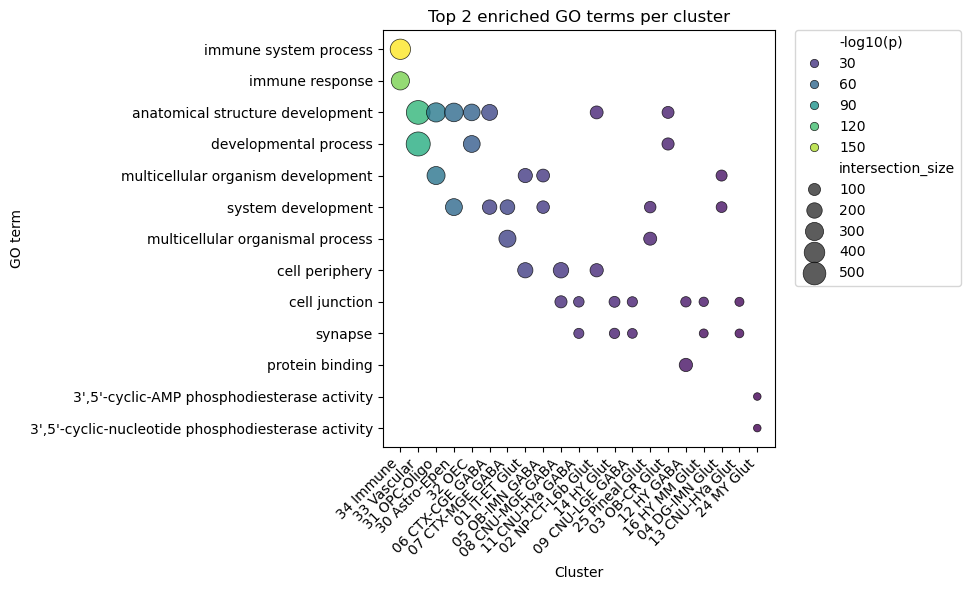

In [ ]:
# ---------------------------------------------
# Parameters
# ---------------------------------------------
top_n = 2  # Top terms per cluster to include

# ---------------------------------------------
# Select top N enriched terms per cluster
# ---------------------------------------------
top_terms_df = (
    go_results_df
    .sort_values("p_value")
    .groupby("cluster")
    .head(top_n)
    .copy()
)

# Shorten term names for better plotting
top_terms_df["term_display"] = top_terms_df["name"].str.slice(0, 50)
top_terms_df["-log10(p)"] = -np.log10(top_terms_df["p_value"] + 1e-300)

# Optional: sort GO terms by frequency of appearance across clusters
term_order = (
    top_terms_df["term_display"]
    .value_counts()
    .index.tolist()
)

# ---------------------------------------------
# Create the Dot Plot
# ---------------------------------------------
plt.figure(figsize=(10, max(6, 0.4 * len(term_order))))
sns.scatterplot(
    data=top_terms_df,
    x="cluster",
    y="term_display",
    size="intersection_size",
    hue="-log10(p)",
    sizes=(30, 300),
    palette="viridis",
    edgecolor="black",
    alpha=0.8,
)

# Improve layout
plt.xticks(rotation=45, ha="right")
plt.ylabel("GO term")
plt.xlabel("Cluster")
plt.title(f"Top {top_n} enriched GO terms per cluster")

# Legends
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

### UMAP: expression of top DEGs in one cluster

### Heatmap: expression of top DEGs across clusters - cluster level

In [16]:
def plot_top_deg_expression_heatmap(adata, deg_results, group_by, n_top_genes=1, agg_func="median"):
    """
    Plot a heatmap of aggregated expression values (mean or median) of top DEGs across clusters.

    Parameters:
    - adata: AnnData object
    - deg_results: DataFrame where each column corresponds to a cluster and contains ranked DEG gene names
    - group_by: Column in adata.obs used to group cells (e.g., "leiden", "louvain")
    - n_top_genes: Number of top genes to include per cluster
    - agg_func: Aggregation function to use, either "median" or "mean"
    """
    if agg_func not in ["median", "mean"]:
        raise ValueError("agg_func must be 'median' or 'mean'")

    # Extract top genes per cluster
    top_deg_genes = []
    gene_cluster_mapping = {}
    for cluster in deg_results.columns:
        cluster_top_genes = deg_results[cluster].dropna().head(n_top_genes).tolist()
        top_deg_genes.extend(cluster_top_genes)
        for gene in cluster_top_genes:
            gene_cluster_mapping[gene] = cluster

    top_deg_genes = list(set(top_deg_genes))  # Remove duplicates

    # Aggregate expression by group
    expression_df = adata[:, top_deg_genes].to_df()
    grouped = expression_df.groupby(adata.obs[group_by])

    if agg_func == "mean":
        aggregated_expression = grouped.mean()
    else:  # median
        aggregated_expression = grouped.median()

    # Maintain cluster order if categorical
    if hasattr(adata.obs[group_by], "cat"):
        cluster_order = adata.obs[group_by].cat.categories
        aggregated_expression = aggregated_expression.loc[cluster_order]
    else:
        cluster_order = aggregated_expression.index.tolist()

    # Order genes based on their original cluster association
    ordered_genes = []
    for cluster in cluster_order:
        cluster_genes = [gene for gene in top_deg_genes if gene_cluster_mapping.get(gene) == cluster]
        ordered_genes.extend(cluster_genes)
    
    aggregated_expression = aggregated_expression[ordered_genes]

    # Plot heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        aggregated_expression.T,
        cmap="viridis",
        cbar_kws={"label": f"{agg_func.capitalize()} Expression"},
        xticklabels=True,
        yticklabels=ordered_genes
    )
    plt.xlabel("Clusters")
    plt.ylabel("Genes")
    plt.title(f"{agg_func.capitalize()} Expression of Top {n_top_genes} DEGs per Cluster")
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_122641/520071919.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = expression_df.groupby(adata.obs[group_by])


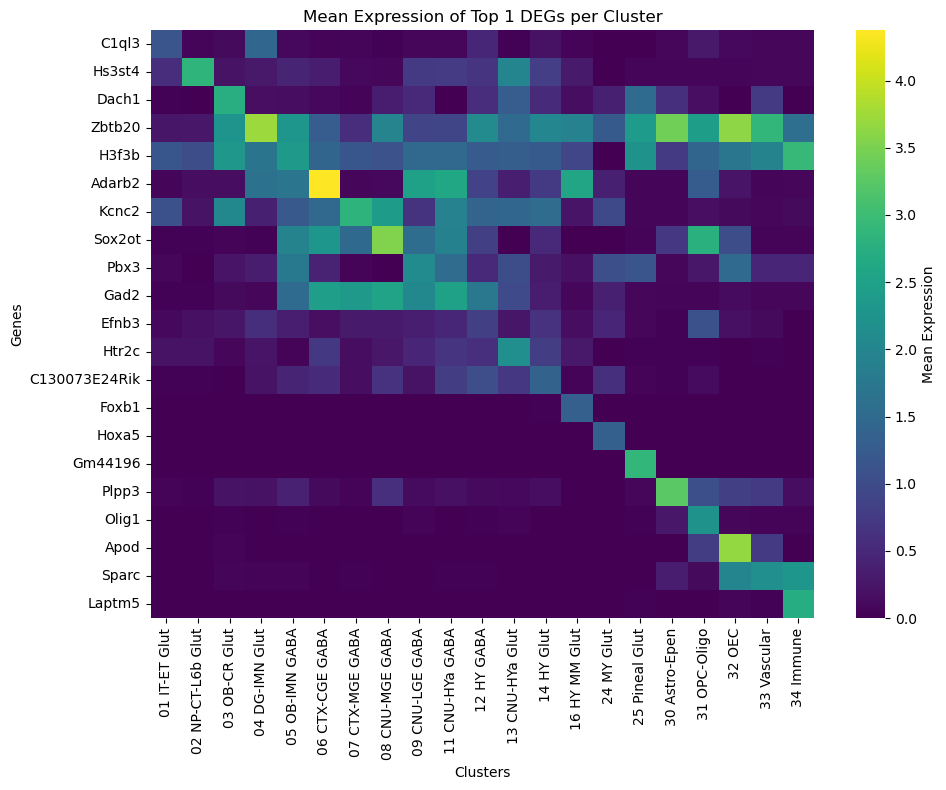

In [17]:
plot_top_deg_expression_heatmap(
    adata=adata,
    deg_results=deg_results,
    group_by="class",
    n_top_genes=1,
    agg_func="mean"
)

### Heatmap: expression of top DEGs across clusters - cell level

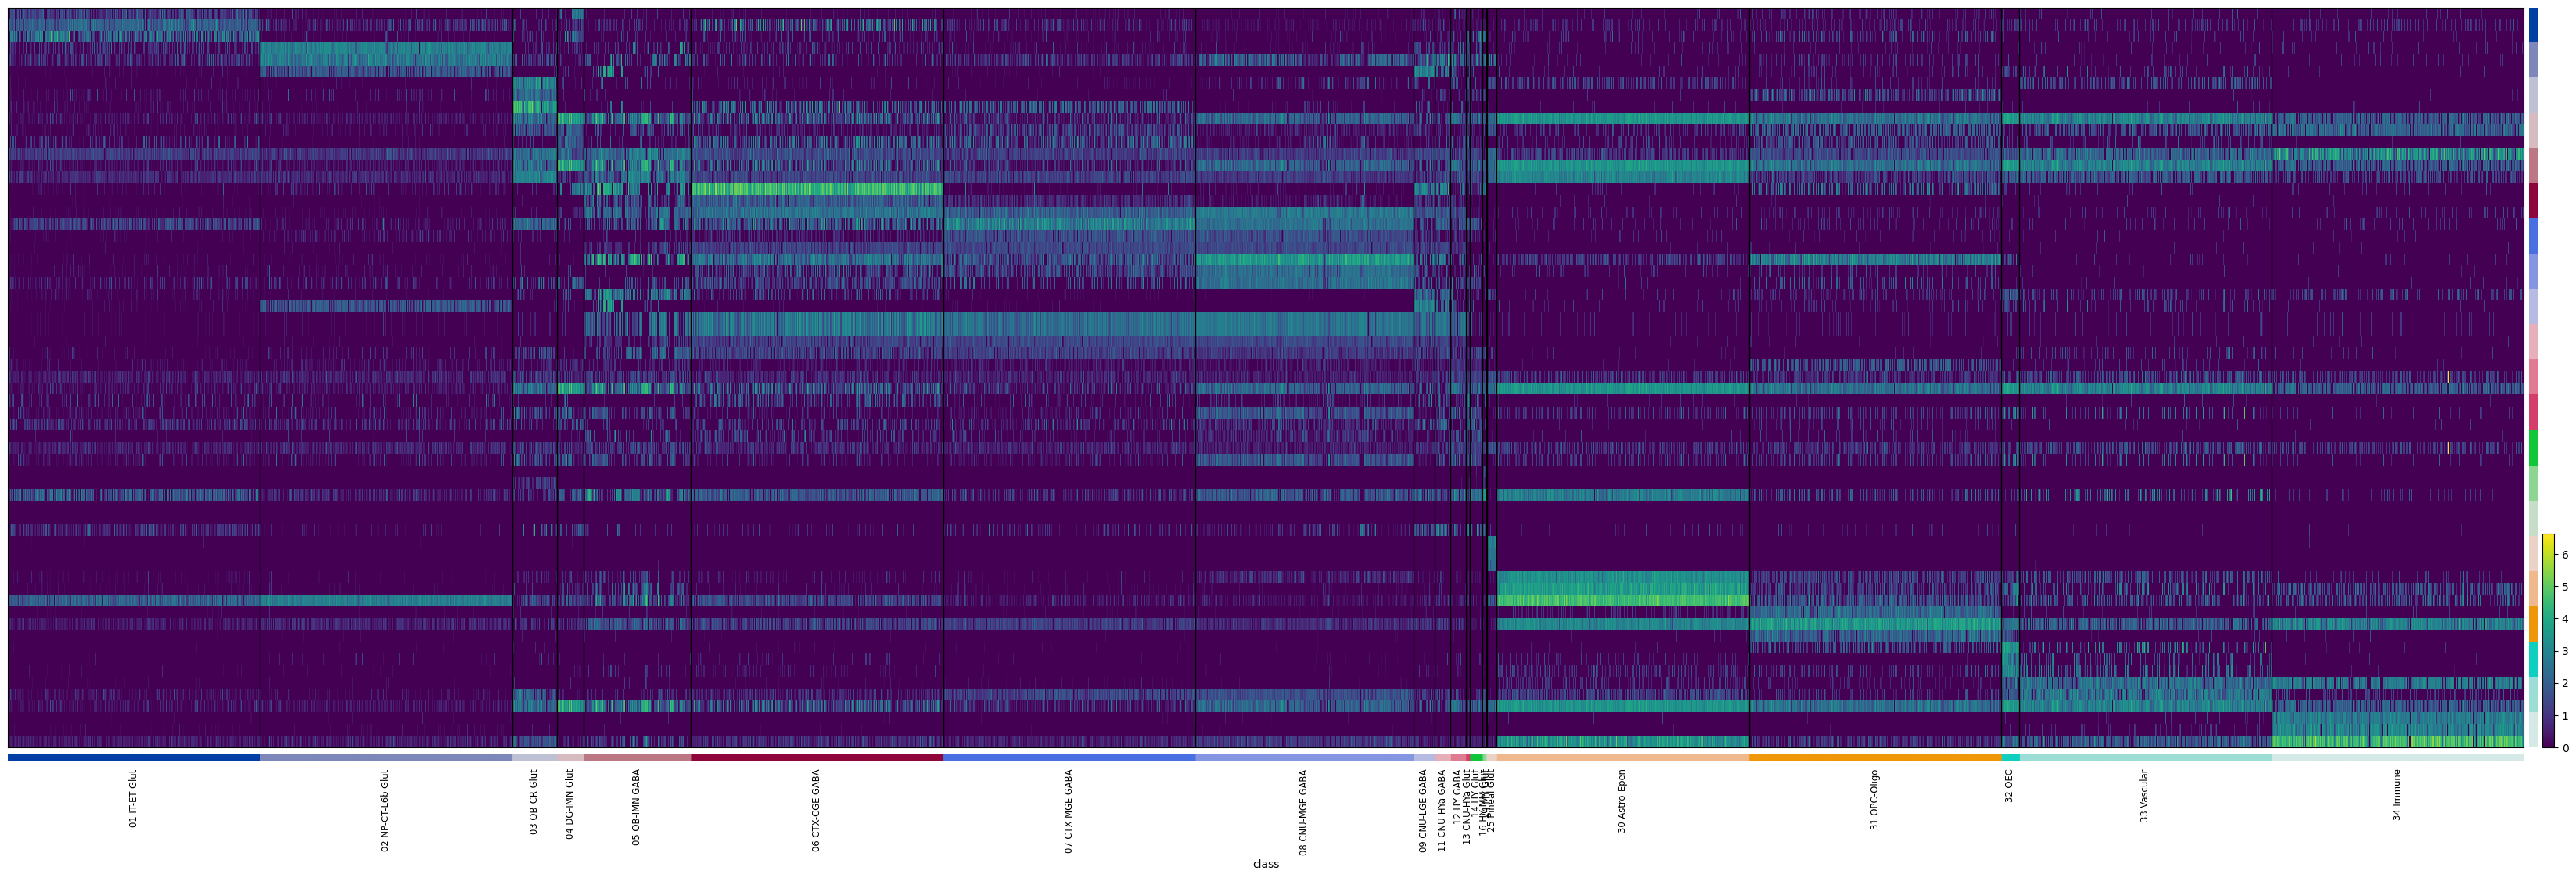

In [15]:
# Define the number of top genes to include per group
n_top_genes = 3

# Extract the top genes for all groups and separate them by group
top_genes_for_heatmap = []
var_group_positions = []
var_group_labels = []
start_idx = 0

for group in deg_results.columns:
    if not deg_results[group].empty:
        group_genes = deg_results[group].dropna().head(n_top_genes).tolist()
        if group_genes:  # Ensure the group has genes
            top_genes_for_heatmap.extend(group_genes)
            var_group_positions.append((start_idx, start_idx + len(group_genes) - 1))
            var_group_labels.append(group)
            start_idx += len(group_genes)

# Compute group sizes
group_sizes = adata.obs[group_by].value_counts()

# Compute scaling factors (normalize based on the largest group)
max_group_size = group_sizes.max() if len(group_sizes) > 0 else 1
scaling_factors = group_sizes / max_group_size  # This replicates your previous calculation

# Store the scaling factors in the AnnData object
adata.obs["scaled_group"] = adata.obs[group_by].map(scaling_factors)

# Downsample cells in large groups to balance the heatmap
max_cells_per_group = 500  # Set a maximum number of cells to display per group

downsampled_indices = []
for group, size in group_sizes.items():
    group_indices = adata.obs[adata.obs[group_by] == group].index.to_list()
    if size > max_cells_per_group:
        sampled_indices = np.random.choice(group_indices, max_cells_per_group, replace=False)
        downsampled_indices.extend(sampled_indices)
    else:
        downsampled_indices.extend(group_indices)

# Ensure correct indexing before subsetting
adata_downsampled = adata[downsampled_indices].copy()

# Adjust the figure size dynamically based on the number of groups and genes
fig_width = max(10, len(var_group_labels) * 2)  # Minimum width of 10, scale with groups
fig_height = max(8, len(top_genes_for_heatmap) * 0.2)  # Minimum height of 8, scale with genes

# Ensure there are genes before plotting
if top_genes_for_heatmap:
    sc.pl.heatmap(
        adata_downsampled,
        var_names=top_genes_for_heatmap,
        groupby=group_by,
        cmap="viridis",
        swap_axes=True,
        figsize=(fig_width, fig_height),
        dendrogram=False,
        var_group_positions=var_group_positions,
        var_group_labels=var_group_labels,
        show=True
    )
else:
    print("No genes selected for the heatmap.")


## Modules

In [18]:
# Loading Module Eigengenes dataframe
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs")
modules_df = pd.read_csv(base_path / f"WMB-10Xv3-{select_region}-raw-mc-wgcna-modules.csv", index_col="Unnamed: 0")
modules_df.head()

,gene_name,module,color,kME_Isocortex-M1,kME_Isocortex-M2,kME_Isocortex-M3,kME_Isocortex-M4,kME_grey,kME_Isocortex-M5,kME_Isocortex-M6,kME_Isocortex-M7,kME_Isocortex-M8,kME_Isocortex-M9
ENSMUSG00000015090,ENSMUSG00000015090,Isocortex-M1,yellow,0.645442,-0.082131,0.055263,0.123491,-0.087391,0.096088,0.129945,0.244009,0.606363,-0.205105
ENSMUSG00000031425,ENSMUSG00000031425,Isocortex-M1,yellow,0.919267,-0.107151,0.070567,0.095239,-0.112462,0.107643,0.243849,0.051845,0.041710,-0.244151
ENSMUSG00000115529,ENSMUSG00000115529,Isocortex-M1,yellow,0.290416,-0.025055,0.009020,0.027299,-0.029463,0.038628,0.236592,0.012456,0.003026,-0.099603
ENSMUSG00000029819,ENSMUSG00000029819,Isocortex-M2,turquoise,-0.003594,0.542115,0.002021,-0.003075,-0.085746,-0.004960,0.046668,0.012330,0.004241,-0.161405
ENSMUSG00000024610,ENSMUSG00000024610,Isocortex-M3,blue,0.006335,-0.033054,0.153545,0.040280,-0.027896,0.001917,-0.002614,0.018507,0.042056,-0.035275


### Heatmap: kME of hub genes across modules

In [19]:
n_top_genes_per_module = 2  # Set the number of top genes to select per module

# Create an empty list to store dataframes for each module
top_genes_by_module = []

# Iterate through each unique module in the "module" column
for module_name in modules_df["module"].unique():
    # Filter the dataframe for the current module
    module_genes = modules_df[modules_df["module"] == module_name]
    
    # Sort the genes by the corresponding kME column in descending order
    sorted_genes = module_genes.sort_values(by=f"kME_{module_name}", ascending=False)
    
    # Select the top genes (you can adjust the number of top genes as needed)
    top_genes = sorted_genes.head(n_top_genes_per_module)
    
    # Append the top genes dataframe to the list
    top_genes_by_module.append(top_genes)

# Combine all the top genes dataframes into a single dataframe
top_genes_df = pd.concat(top_genes_by_module, ignore_index=True)

# Display the resulting dataframe
top_genes_df.head()

,gene_name,module,color,kME_Isocortex-M1,kME_Isocortex-M2,kME_Isocortex-M3,kME_Isocortex-M4,kME_grey,kME_Isocortex-M5,kME_Isocortex-M6,kME_Isocortex-M7,kME_Isocortex-M8,kME_Isocortex-M9
0,ENSMUSG00000033579,Isocortex-M1,yellow,0.931046,-0.094431,0.014312,0.035500,-0.096881,0.045765,0.305594,0.001473,0.003802,-0.213210
1,ENSMUSG00000037625,Isocortex-M1,yellow,0.926951,-0.103769,0.018537,0.047911,-0.095544,0.037631,0.131973,0.026364,0.068962,-0.209419
2,ENSMUSG00000026787,Isocortex-M2,turquoise,-0.011908,0.913981,-0.012700,-0.016992,-0.158939,-0.021097,0.069336,0.004123,-0.000682,-0.266210
3,ENSMUSG00000037771,Isocortex-M2,turquoise,-0.016164,0.903847,-0.018195,-0.022709,-0.157596,-0.028394,0.060217,-0.002996,-0.001836,-0.259361
4,ENSMUSG00000024621,Isocortex-M3,blue,0.032446,-0.113386,0.967422,0.084476,-0.085543,0.008932,-0.022843,-0.010405,-0.004951,-0.200912


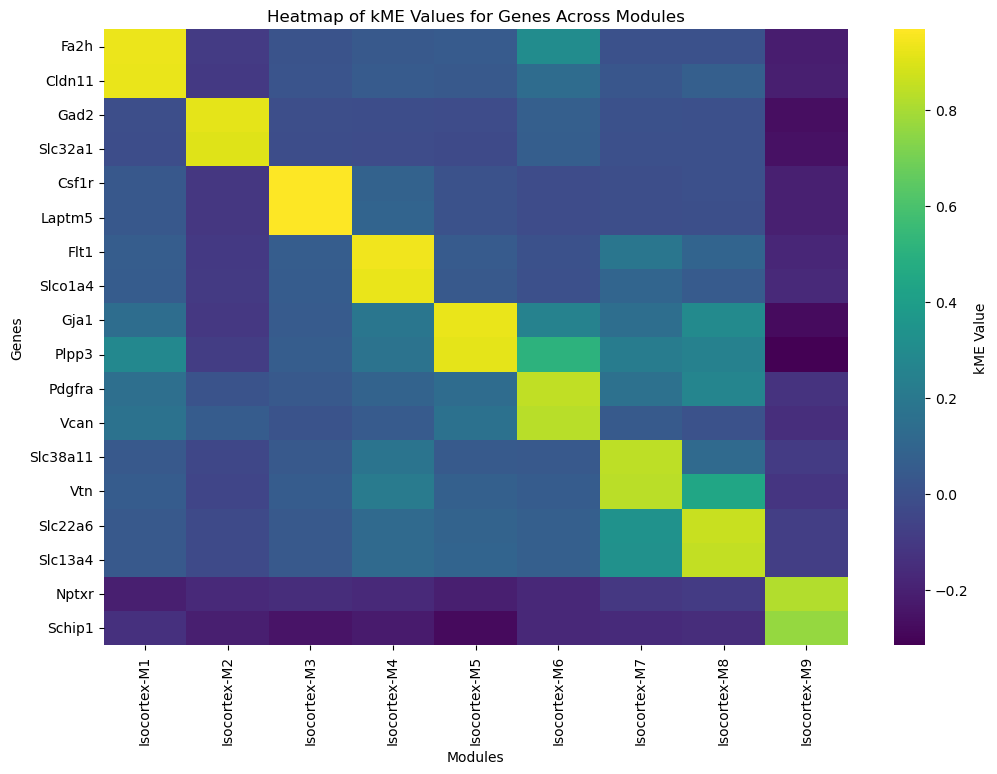

In [20]:
# Map gene IDs to gene symbols
gene_symbol_mapping = gene_names_df["gene_symbol"].to_dict()
top_genes_df["gene_symbol"] = top_genes_df["gene_name"].map(gene_symbol_mapping)

# Prepare the data for the heatmap
heatmap_data = top_genes_df.set_index("gene_symbol")[[f"kME_{module}" for module in top_genes_df["module"].unique()]]
heatmap_data.columns = [col.replace("kME_", "") for col in heatmap_data.columns]  # Simplify column names

# Create the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    cmap="viridis",
    annot=False,
    cbar_kws={"label": "kME Value"}
)

# Set axis labels and title
plt.xlabel("Modules")
plt.ylabel("Genes")
plt.title("Heatmap of kME Values for Genes Across Modules")

plt.show()

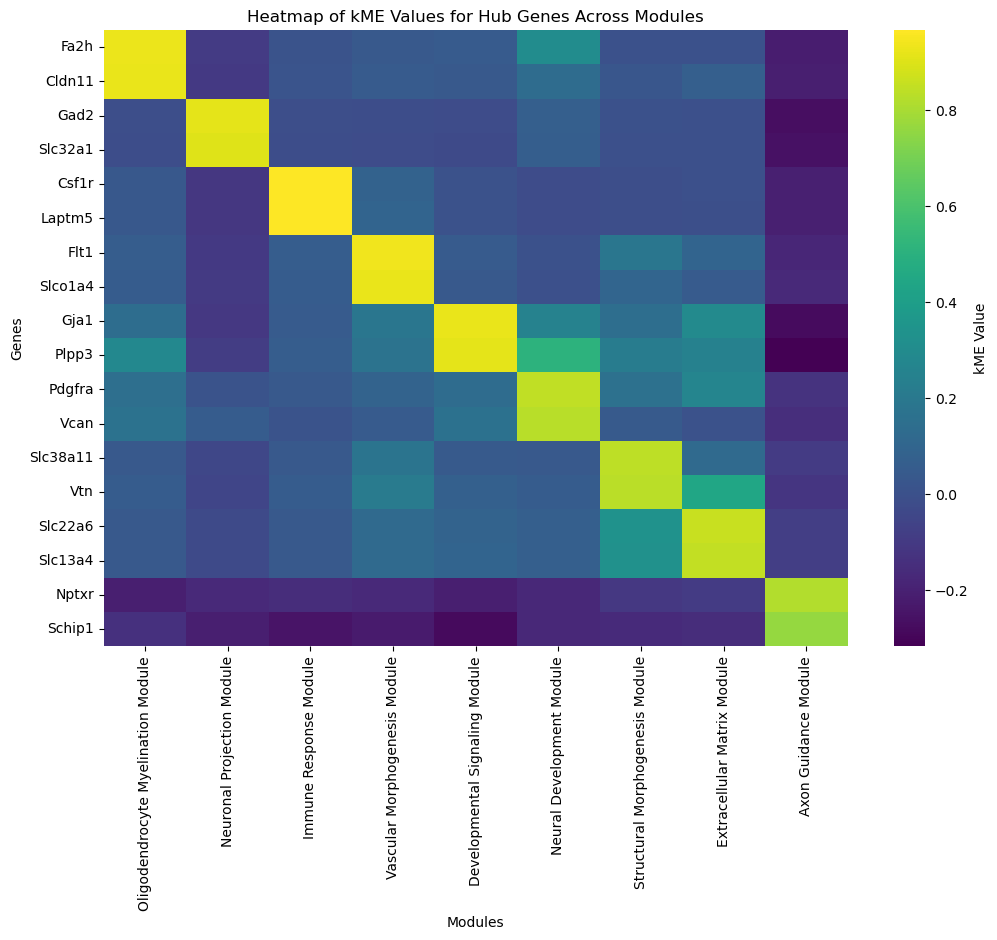

In [21]:
# Map gene IDs to gene symbols
gene_symbol_mapping = gene_names_df["gene_symbol"].to_dict()
top_genes_df["gene_symbol"] = top_genes_df["gene_name"].map(gene_symbol_mapping)

# Define a dictionary with old module names as keys and new module names as values
module_name_mapping = {
    "Isocortex-M1": "Oligodendrocyte Myelination Module",
    "Isocortex-M2": "Neuronal Projection Module",
    "Isocortex-M3": "Immune Response Module",
    "Isocortex-M4": "Vascular Morphogenesis Module",
    "Isocortex-M5": "Developmental Signaling Module",
    "Isocortex-M6": "Neural Development Module",
    "Isocortex-M7": "Structural Morphogenesis Module",
    "Isocortex-M8": "Extracellular Matrix Module",
    "Isocortex-M9": "Axon Guidance Module",
}

# Prepare the data for the heatmap
heatmap_data = top_genes_df.set_index("gene_symbol")[[f"kME_{module}" for module in top_genes_df["module"].unique()]]
heatmap_data.columns = [
    module_name_mapping.get(col.replace("kME_", ""), col.replace("kME_", ""))
    for col in heatmap_data.columns
]

# Create the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    cmap="viridis",
    annot=False,
    cbar_kws={"label": "kME Value"}
)

# Set axis labels and title
plt.xlabel("Modules")
plt.ylabel("Genes")
plt.title("Heatmap of kME Values for Hub Genes Across Modules")

plt.show()
